<!-- notebook-header -->
# Arquiteturas de Deep Learning

**Modulo:** 04 - Deep Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** CNNs, RNNs, Transformers, profundidade, conectividade e hierarquia de features.


# Arquiteturas de Deep Learning: CNNs, RNNs e Transformers

## Pre-requisitos e Fio Narrativo

**Pre-requisitos:** 4.1 (fundamentos de redes neurais, backpropagation)
**Tempo estimado:** 14 horas
**Objetivo:** Entender as tres grandes familias de arquiteturas: CNNs (imagens), RNNs/LSTMs (sequencias), e Transformers (tudo).

**Fio narrativo:** No notebook 4.1, aprendemos MLPs genericos. Mas MLPs tratam cada input como independente -- nao sabem que pixels vizinhos sao correlacionados (imagens) nem que palavras anteriores importam (texto). As arquiteturas deste notebook adicionam **inductive biases** inteligentes: CNNs exploram localidade espacial, RNNs exploram sequencialidade temporal, e Transformers exploram relacoes entre quaisquer elementos. A evolucao CNN -> RNN -> LSTM -> Attention -> Transformer e a historia do deep learning moderno.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

def make_blobs(n_samples=100, centers=2, n_features=2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    y = np.zeros(n_samples, dtype=int)
    center_size = n_samples // centers
    for c in range(centers):
        start = c * center_size
        end = start + center_size if c < centers - 1 else n_samples
        offset = np.random.randn(n_features) * 2
        X[start:end] += offset
        y[start:end] = c
    return X, y


## 1. Hierarquia de Features em Redes Profundas

### Analogia / Intuicao

O sistema visual humano processa imagens em niveis: retina detecta arestas, area V1 combina arestas em cantos, V2 detecta formas, e areas superiores reconhecem objetos. CNNs fazem o mesmo: camada 1 aprende arestas, camada 2 aprende texturas, camada 3 aprende partes de objetos, camada 4 aprende objetos inteiros. Cada camada cria representacoes mais **abstratas**.

### Definicao Formal

Uma rede profunda com L camadas computa: $f(x) = f_L \circ f_{L-1} \circ ... \circ f_1(x)$

Cada $f_l$ transforma a representacao, criando uma hierarquia:
- $f_1(x)$: features de baixo nivel (arestas, cores)
- $f_l(x)$: features intermediarias (texturas, formas)
- $f_L(x)$: features de alto nivel (objetos, conceitos)

### Por que em ML?

A hierarquia de features e a razao pela qual deep learning supera feature engineering manual. Em vez de definir "o que e uma aresta", a rede aprende automaticamente o que cada camada deve detectar. Isso torna deep learning aplicavel a problemas onde nao sabemos quais features sao importantes.

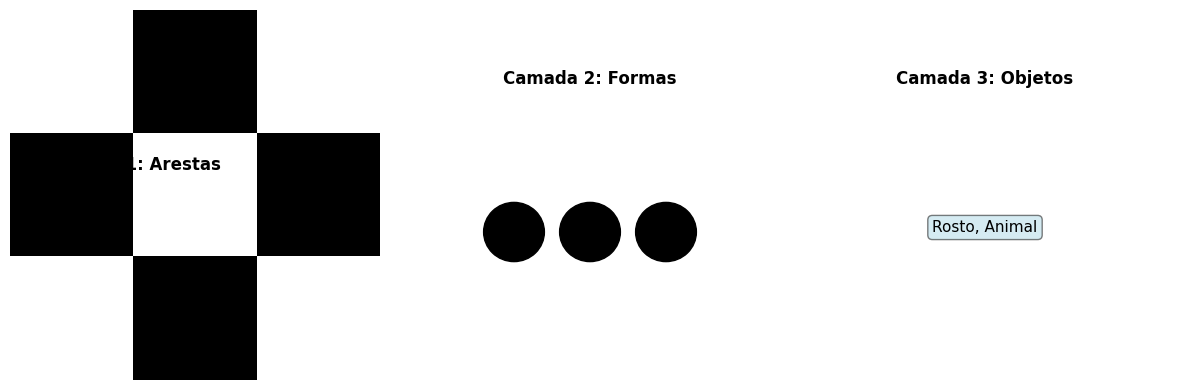

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ax = axes[0]
ax.text(0.5, 0.8, 'Camada 1: Arestas', fontsize=12, weight='bold', ha='center')
ax.imshow(np.array([[1,0,1], [0,1,0], [1,0,1]]), cmap='gray')
ax.axis('off')

ax = axes[1]
ax.text(0.5, 0.8, 'Camada 2: Formas', fontsize=12, weight='bold', ha='center')
for i in range(3):
    circle = plt.Circle((0.3 + i*0.2, 0.4), 0.08, fill=True, color='black')
    ax.add_patch(circle)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax = axes[2]
ax.text(0.5, 0.8, 'Camada 3: Objetos', fontsize=12, weight='bold', ha='center')
ax.text(0.5, 0.4, 'Rosto, Animal', ha='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### O que observar

- Camada 1 detecta padroes simples (arestas basicas)
- Camada 2 combina arestas em formas geometricas
- Camada 3 combina formas em conceitos semanticos (rosto, animal)
- Cada camada reutiliza a saida da anterior -- composicionalidade

### O que concluir

- Profundidade e crucial: uma unica camada nao consegue pular de pixels para objetos
- A hierarquia e emergente: a rede descobre sozinha o que detectar em cada nivel
- Mais camadas = representacoes mais abstratas, mas tambem mais dificil de treinar

### Conexao com outros notebooks

- Em **4.1 Fundamentos**, MLP plano nao explora estrutura espacial -- CNN corrige isso
- Em **3.6 Reducao**, PCA tambem cria representacoes mais compactas, mas de forma linear

## 2. Convolucao 2D: A Operacao Fundamental

### Analogia / Intuicao

Imagine uma lupa deslizando sobre uma foto. Em cada posicao, a lupa "multiplica" os pixels por um padrao (kernel) e soma. Se o padrao da lupa corresponder ao que esta na foto, o resultado e alto. Diferentes lupas detectam diferentes coisas: uma lupa horizontal detecta arestas horizontais, uma vertical detecta verticais. CNN aprende **automaticamente** os melhores kernels.

### Definicao Formal

Convolucao 2D: $(I * K)[i,j] = \sum_m \sum_n I[i+m, j+n] \cdot K[m,n]$

Propriedades chave:
- **Weight sharing:** o mesmo kernel e aplicado em todas as posicoes (menos parametros)
- **Localidade:** cada neuronio ve apenas uma regiao local da entrada
- **Equivariancia de translacao:** se o objeto move, a deteccao move junto

### Por que em ML?

Convolucao reduz drasticamente o numero de parametros: em vez de conectar cada pixel a cada neuronio (MLP), compartilha pesos via kernel. Uma imagem 224x224 com MLP teria ~150k parametros por neuronio; com conv 3x3, apenas 9.

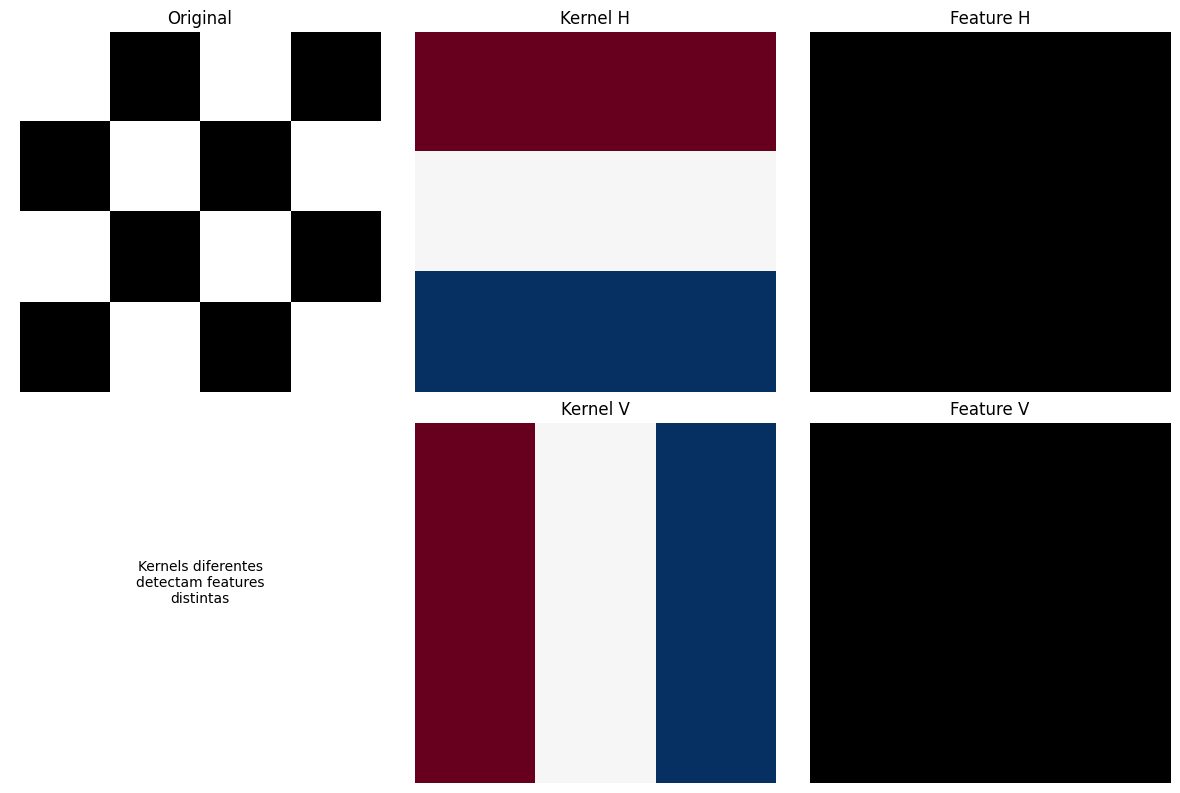

In [3]:
def conv2d_simple(image, kernel):
    h_i, w_i = image.shape
    h_k, w_k = kernel.shape
    output = np.zeros((h_i - h_k + 1, w_i - w_k + 1))
    
    for i in range(h_i - h_k + 1):
        for j in range(w_i - w_k + 1):
            output[i, j] = np.sum(image[i:i+h_k, j:j+w_k] * kernel)
    
    return output

image = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 0, 1]
])

kernel_h = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
kernel_v = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

feature_h = conv2d_simple(image, kernel_h)
feature_v = conv2d_simple(image, kernel_v)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(kernel_h, cmap='RdBu')
axes[0, 1].set_title('Kernel H')
axes[0, 1].axis('off')

axes[0, 2].imshow(np.abs(feature_h), cmap='gray')
axes[0, 2].set_title('Feature H')
axes[0, 2].axis('off')

axes[1, 1].imshow(kernel_v, cmap='RdBu')
axes[1, 1].set_title('Kernel V')
axes[1, 1].axis('off')

axes[1, 2].imshow(np.abs(feature_v), cmap='gray')
axes[1, 2].set_title('Feature V')
axes[1, 2].axis('off')

axes[1, 0].text(0.5, 0.5, 'Kernels diferentes\ndetectam features\ndistintas', ha='center')
axes[1, 0].axis('off')

plt.tight_layout()
plt.show()

### O que observar

- O kernel horizontal [-1,-1,-1; 0,0,0; 1,1,1] detecta transicoes verticais (arestas horizontais)
- O kernel vertical detecta transicoes horizontais (arestas verticais)
- O feature map resultante tem valores altos onde a aresta foi encontrada
- A saida e menor que a entrada (sem padding): (4,4) convolvido com (3,3) da (2,2)

### O que concluir

- Kernels diferentes detectam features diferentes -- CNN aprende os melhores
- Weight sharing (mesmo kernel em toda a imagem) e a chave da eficiencia
- Na pratica, CNNs usam dezenas de kernels por camada, cada um detectando algo diferente
- Stride e padding controlam o tamanho da saida

### Conexao com outros notebooks

- Em **3.6 Reducao**, PCA tambem extrai features, mas globais (nao locais como convolucao)
- Em **4.1 Fundamentos**, MLP conecta tudo-com-tudo; conv e uma versao esparsa e compartilhada

## 3. Max Pooling e Reducao Espacial

### Por que em ML?

Pooling reduz a dimensionalidade espacial progressivamente: 224x224 -> 112x112 -> 56x56 -> ... -> 7x7. Isso traz invariancia de translacao (pequenos deslocamentos nao afetam o resultado) e reduz o numero de parametros nas camadas seguintes.

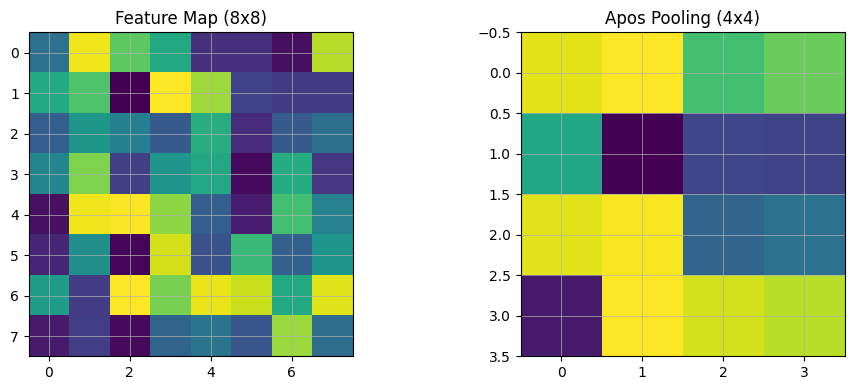

Dimensionalidade: (8, 8) -> (4, 4)


In [4]:
def max_pooling(feature_map, pool_size=2):
    h, w = feature_map.shape
    output_h, output_w = h // pool_size, w // pool_size
    output = np.zeros((output_h, output_w))
    
    for i in range(output_h):
        for j in range(output_w):
            output[i, j] = np.max(feature_map[i*pool_size:(i+1)*pool_size,
                                                j*pool_size:(j+1)*pool_size])
    return output

feature_large = np.random.rand(8, 8)
pooled = max_pooling(feature_large, pool_size=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(feature_large, cmap='viridis')
axes[0].set_title('Feature Map (8x8)')
axes[0].grid(True, which='both', linewidth=0.5)

axes[1].imshow(pooled, cmap='viridis')
axes[1].set_title('Apos Pooling (4x4)')
axes[1].grid(True, which='both', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Dimensionalidade: {feature_large.shape} -> {pooled.shape}')

### O que observar

- Max pooling 2x2 reduz cada dimensao pela metade: 8x8 -> 4x4
- Mantem o valor maximo de cada regiao (preserva features mais fortes)
- Reducao de 4x em parametros por camada de pooling
- A perda de resolucao e intencional: forca a rede a aprender representacoes mais abstratas

### O que concluir

- Max pooling e a forma padrao de reducao em CNNs (alternativa: stride > 1 na convolucao)
- Muito pooling perde informacao; pouco pooling nao reduz suficientemente
- Arquiteturas modernas (ResNet, EfficientNet) usam menos pooling e mais stride
- Average pooling global e usado na camada final antes do classificador

### Conexao com outros notebooks

- Em **3.5 Clustering**, reducao de dimensionalidade tambem remove informacao redundante
- Em **3.6 Reducao**, PCA comprime globalmente; pooling comprime localmente

## 4. Evolucao das Arquiteturas CNN

### Por que em ML?

A historia das CNNs e uma licao de design: cada nova arquitetura resolve um problema da anterior. LeNet mostrou que CNNs funcionam; AlexNet escalou para GPUs; VGG mostrou que profundidade importa; ResNet resolveu o vanishing gradient em redes muito profundas; EfficientNet otimizou o trade-off tamanho-performance.

In [5]:
arch_data = [
    {'Arquitetura': 'LeNet', 'Ano': 1998, 'Parametros': '60k'},
    {'Arquitetura': 'AlexNet', 'Ano': 2012, 'Parametros': '60M'},
    {'Arquitetura': 'VGG-16', 'Ano': 2014, 'Parametros': '138M'},
    {'Arquitetura': 'ResNet-50', 'Ano': 2015, 'Parametros': '25M'},
    {'Arquitetura': 'EfficientNet', 'Ano': 2019, 'Parametros': '5.3M-340M'}
]

arch_df = pd.DataFrame(arch_data)
print('Arquiteturas CNN Classicas:')
print(arch_df.to_string(index=False))

Arquiteturas CNN Classicas:
 Arquitetura  Ano Parametros
       LeNet 1998        60k
     AlexNet 2012        60M
      VGG-16 2014       138M
   ResNet-50 2015        25M
EfficientNet 2019  5.3M-340M


### O que observar

- De LeNet (60k params) a VGG-16 (138M params): explosao de tamanho
- ResNet-50 e MENOR que VGG-16 mas MELHOR: residual connections sao mais eficientes
- EfficientNet varia de 5.3M a 340M: familia escalavel por design
- A tendencia moderna e redes menores mas mais inteligentes (nao so maiores)

### O que concluir

- Mais parametros nem sempre e melhor -- arquitetura importa mais que tamanho
- Residual connections (skip connections) resolveram o treinamento de redes muito profundas
- Para aplicacoes reais, usar arquiteturas pre-treinadas (transfer learning, notebook 4.4)
- A escolha da arquitetura depende do problema e dos recursos computacionais

### Conexao com outros notebooks

- Em **4.4 Transfer Learning**, usaremos essas arquiteturas pre-treinadas como base
- Em **4.5 Aceleracao**, o tamanho da rede afeta diretamente o custo computacional

## 5. RNN: Redes Recorrentes para Sequencias

### Analogia / Intuicao

Imagine ler uma frase palavra por palavra. A cada nova palavra, voce atualiza sua compreensao do texto usando (1) a nova palavra e (2) o que ja entendeu ate agora. RNN faz exatamente isso: mantem um "estado oculto" $h_t$ que resume tudo que viu ate o timestep $t$. E como uma memoria de curto prazo que e atualizada a cada passo.

### Definicao Formal

$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b_h)$
$y_t = W_y \cdot h_t + b_y$

Os pesos $W_h, W_x, W_y$ sao **compartilhados** em todos os timesteps (weight sharing temporal).

### Por que em ML?

RNNs sao o analogo temporal das CNNs: assim como CNNs exploram localidade espacial, RNNs exploram dependencias temporais. Usadas em NLP, series temporais, audio, e qualquer dado sequencial.

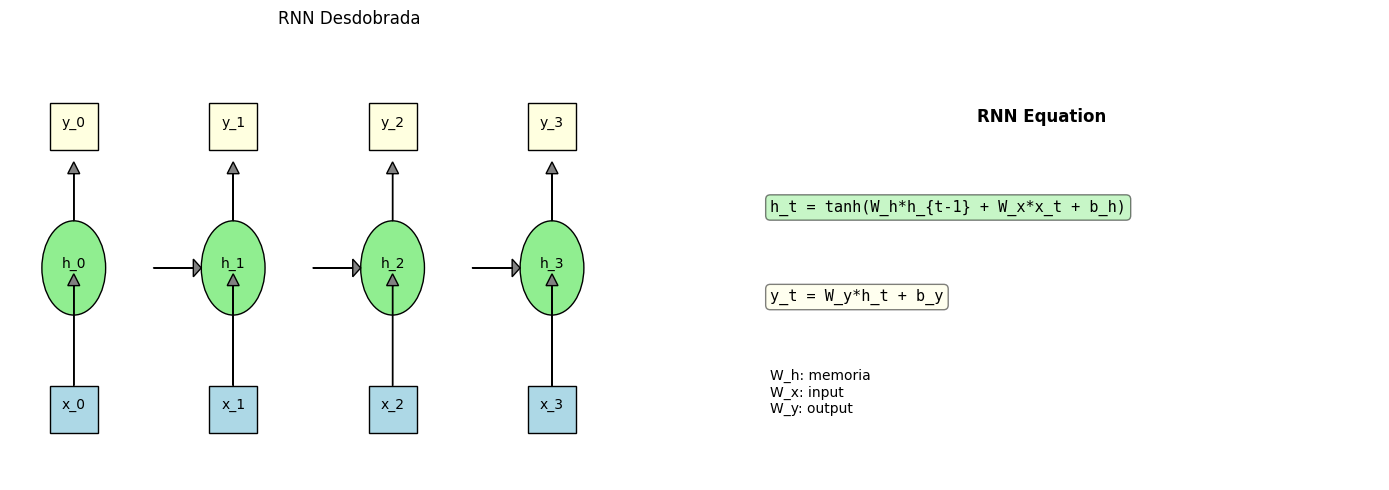

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
time_steps = 4
for t in range(time_steps):
    ax.add_patch(plt.Rectangle((t*2, 0.1), 0.6, 0.4, fill=True, color='lightblue', ec='black'))
    ax.text(t*2+0.3, 0.3, f'x_{t}', ha='center', fontsize=10)
    ax.add_patch(plt.Circle((t*2+0.3, 1.5), 0.4, fill=True, color='lightgreen', ec='black'))
    ax.text(t*2+0.3, 1.5, f'h_{t}', ha='center', fontsize=10)
    ax.add_patch(plt.Rectangle((t*2, 2.5), 0.6, 0.4, fill=True, color='lightyellow', ec='black'))
    ax.text(t*2+0.3, 2.7, f'y_{t}', ha='center', fontsize=10)
    
    if t > 0:
        ax.arrow(t*2-0.7, 1.5, 0.5, 0, head_width=0.15, head_length=0.1, fc='gray')
    ax.arrow(t*2+0.3, 0.5, 0, 0.85, head_width=0.15, head_length=0.1, fc='gray')
    ax.arrow(t*2+0.3, 1.9, 0, 0.4, head_width=0.15, head_length=0.1, fc='gray')

ax.set_xlim(-0.5, 8)
ax.set_ylim(-0.3, 3.5)
ax.axis('off')
ax.set_title('RNN Desdobrada')

ax = axes[1]
ax.text(0.5, 0.8, 'RNN Equation', fontsize=12, weight='bold', ha='center')
ax.text(0.1, 0.6, 'h_t = tanh(W_h*h_{t-1} + W_x*x_t + b_h)',
        fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.text(0.1, 0.4, 'y_t = W_y*h_t + b_y',
        fontsize=11, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
ax.text(0.1, 0.15, 'W_h: memoria\nW_x: input\nW_y: output',
        fontsize=10, ha='left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### O que observar

- Cada timestep recebe input $x_t$ e estado anterior $h_{t-1}$
- O estado $h_t$ acumula informacao de todos os passos anteriores
- Os mesmos pesos $W_h$ sao reutilizados em cada passo (eficiencia)
- A saida $y_t$ pode ser gerada em cada passo ou apenas no final

### O que concluir

- RNN e inerentemente sequencial: nao pode processar $x_3$ antes de $x_2$ (limitacao de paralelismo)
- O estado $h_t$ tenta comprimir toda a historia em um vetor fixo -- problematico para sequencias longas
- Vanishing gradient: ao retropropagar por muitos timesteps, gradientes desaparecem ($\tanh$ derivada < 1)
- Solucao: LSTM, que usa gates e cell state para preservar gradientes

### Conexao com outros notebooks

- Em **4.1 Fundamentos**, backpropagation em MLP e analogo; em RNN e chamado BPTT (Backprop Through Time)
- Em **0.3 Calculo**, a regra da cadeia aplicada T vezes e o que causa vanishing gradient

## 6. LSTM: Resolvendo o Vanishing Gradient

### Analogia / Intuicao

LSTM e como um "correio de valor": a informacao importante (cell state) flui por um tubo protegido. Tres porteiros (gates) controlam o que entra, o que sai, e o que e descartado. Diferente de RNN simples onde a "mensagem" e reescrita a cada passo, LSTM pode **manter** informacao por centenas de passos.

### Definicao Formal

- **Forget gate:** $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ -- quanto manter do passado
- **Input gate:** $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ -- quanto de novo aceitar
- **Cell state:** $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ -- fluxo aditivo (nao multiplicativo!)
- **Output gate:** $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$

A chave: $C_t$ usa **adicao** (nao multiplicacao), permitindo que gradientes fluam diretamente.

### Por que em ML?

LSTM resolveu o problema fundamental que impedia RNNs de funcionar em sequencias longas. Sem LSTM, nao teriamos tradução automatica, reconhecimento de fala, ou geracao de texto (pre-Transformers). GRU e uma variante simplificada com 2 gates em vez de 3.

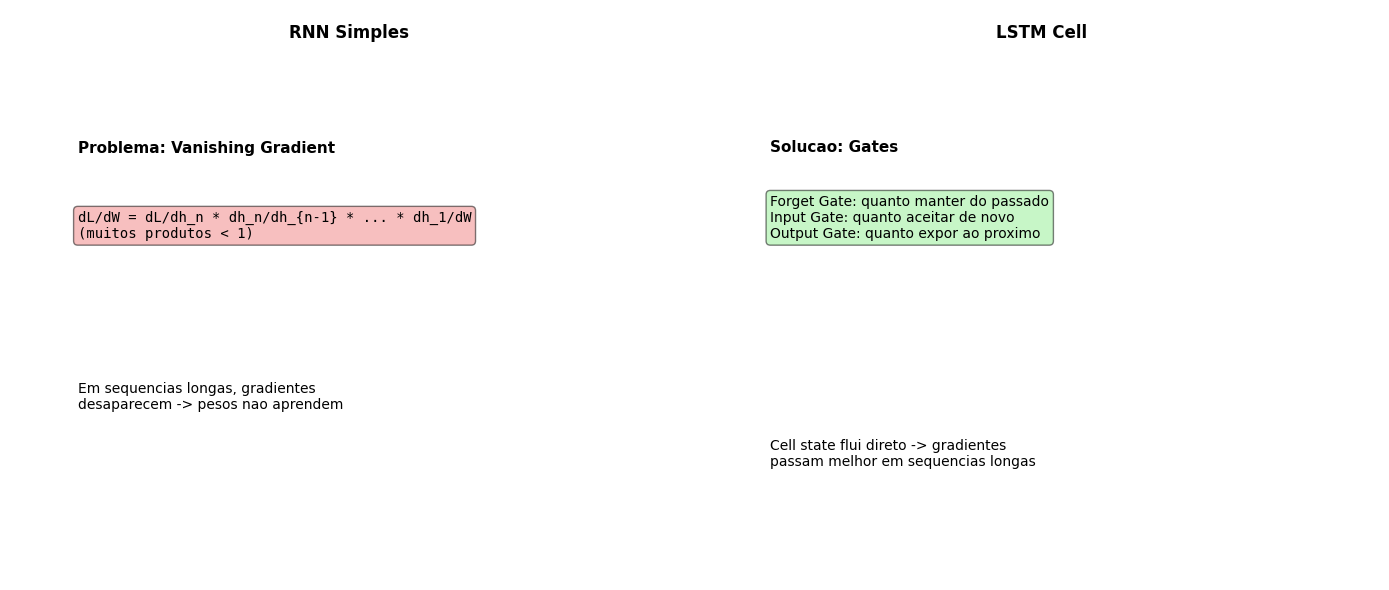

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.text(0.5, 0.95, 'RNN Simples', fontsize=12, weight='bold', ha='center')
ax.text(0.1, 0.75, 'Problema: Vanishing Gradient', fontsize=11, weight='bold')
ax.text(0.1, 0.6, 'dL/dW = dL/dh_n * dh_n/dh_{n-1} * ... * dh_1/dW\n(muitos produtos < 1)', 
        fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax.text(0.1, 0.3, 'Em sequencias longas, gradientes\ndesaparecem -> pesos nao aprendem',
        fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax = axes[1]
ax.text(0.5, 0.95, 'LSTM Cell', fontsize=12, weight='bold', ha='center')
ax.text(0.1, 0.75, 'Solucao: Gates', fontsize=11, weight='bold')
ax.text(0.1, 0.6, 'Forget Gate: quanto manter do passado\nInput Gate: quanto aceitar de novo\nOutput Gate: quanto expor ao proximo',
        fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.text(0.1, 0.2, 'Cell state flui direto -> gradientes\npassam melhor em sequencias longas',
        fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### O que observar

- RNN simples: gradientes multiplicam por derivada < 1 em cada passo -> desaparecem
- LSTM: cell state flui com operacao ADITIVA -> gradientes nao desaparecem
- Os gates sao redes neurais pequenas que aprendem QUANDO esquecer/lembrar
- LSTM tem ~4x mais parametros que RNN (3 gates + cell update)

### O que concluir

- LSTM e a solucao padrao para sequencias longas (>20 timesteps)
- GRU simplifica LSTM (2 gates) com performance similar na maioria dos casos
- Para sequencias muito longas (>500), mesmo LSTM pode ter dificuldades -> Attention e Transformers
- Na pratica moderna, Transformers substituiram LSTM na maioria das aplicacoes de NLP

### Conexao com outros notebooks

- Em **4.1 Fundamentos**, vanishing gradient em MLPs com sigmoid e o mesmo problema
- Em **4.3 Treinamento**, gradient clipping e outra tecnica para lidar com gradientes explosivos

## 7. Mecanismo de Attention

### Analogia / Intuicao

Quando voce le "O gato sentou no tapete porque ele estava cansado", ao processar "ele", seu cerebro automaticamente foca em "gato" (nao em "tapete"). Attention faz o mesmo: para cada elemento da sequencia, calcula **pesos de relevancia** sobre todos os outros elementos e combina ponderadamente.

### Definicao Formal

$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$

- **Q (Query):** "o que estou procurando?"
- **K (Key):** "o que cada elemento oferece?"
- **V (Value):** "qual a informacao de cada elemento?"
- $\sqrt{d_k}$: normalizacao para estabilizar gradientes

### Por que em ML?

Attention permite conexoes **diretas** entre quaisquer dois elementos da sequencia, independente da distancia. RNN precisa de T passos para conectar o primeiro e ultimo elemento; Attention faz em 1 passo. Isso melhora tanto a qualidade (captura dependencias longas) quanto a velocidade (paralelizavel).

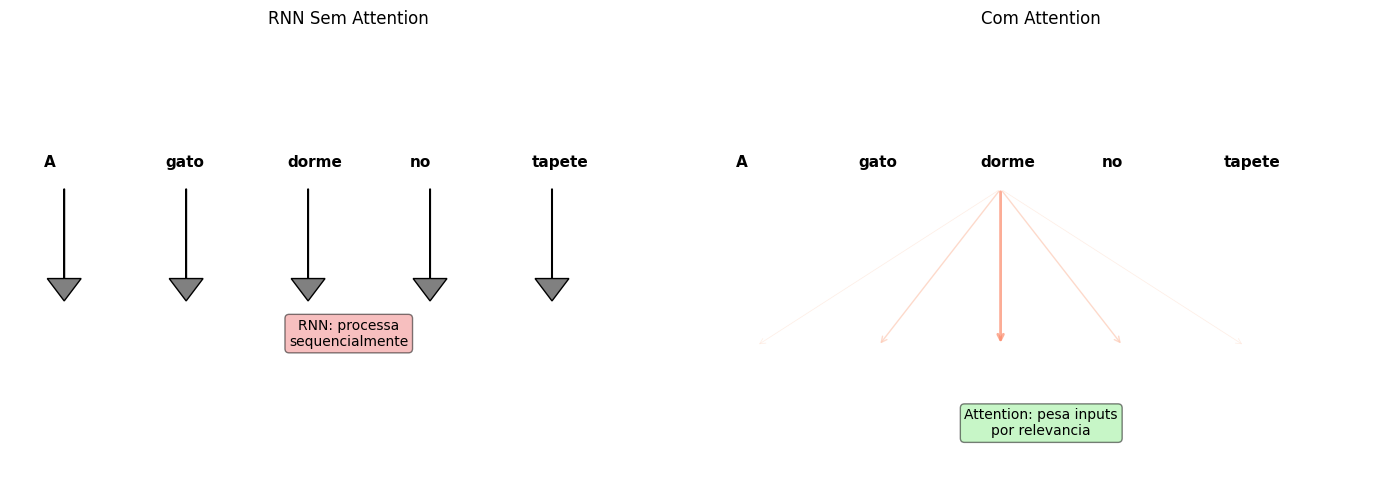

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sentence = ['A', 'gato', 'dorme', 'no', 'tapete']
for i, word in enumerate(sentence):
    ax.text(i*0.18+0.05, 0.7, word, fontsize=11, weight='bold')
    ax.arrow(i*0.18+0.08, 0.65, 0, -0.2, head_width=0.05, head_length=0.05, fc='gray')

ax.text(0.5, 0.3, 'RNN: processa\nsequencialmente',
        ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('RNN Sem Attention')

ax = axes[1]
for i, word in enumerate(sentence):
    ax.text(i*0.18+0.05, 0.7, word, fontsize=11, weight='bold')

query_idx = 2
attention_weights = [0.1, 0.2, 0.4, 0.2, 0.1]

for i, weight in enumerate(attention_weights):
    y_from = 0.65
    y_to = 0.3
    ax.annotate('', xy=(i*0.18+0.08, y_to), xytext=(query_idx*0.18+0.08, y_from),
               arrowprops=dict(arrowstyle='->', color=plt.cm.Reds(weight), lw=weight*5, alpha=0.7))

ax.text(0.5, 0.1, 'Attention: pesa inputs\npor relevancia',
        ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Com Attention')

plt.tight_layout()
plt.show()

### O que observar

- Sem attention, RNN processa sequencialmente e pode "esquecer" informacao distante
- Com attention, cada palavra pode "olhar" diretamente para qualquer outra
- Os pesos de attention sao aprendidos e especificos para cada par de palavras
- Linhas mais grossas = mais relevancia na atencao

### O que concluir

- Attention e a inovacao que levou aos Transformers e a era atual de LLMs
- Multi-head attention usa varios "heads" simultaneos, cada um focando em aspectos diferentes
- Self-attention (mesma sequencia como Q, K, V) e a base do Transformer
- Attention e O(n^2) em relacao ao comprimento da sequencia -- limitacao para textos muito longos

### Conexao com outros notebooks

- Em **3.4 SVM**, kernel trick computa similaridade entre pontos; attention computa similaridade entre tokens
- Em **4.4 Transfer Learning**, modelos pre-treinados como BERT usam self-attention internamente

## 8. Transformer: A Arquitetura que Mudou Tudo

### Analogia / Intuicao

Imagine uma sala de aula onde cada aluno (token) pode fazer perguntas para qualquer outro aluno simultaneamente. RNN e como um telefone sem fio (informacao passa em sequencia); Transformer e como uma reuniao aberta (todos se comunicam diretamente). Isso e massivamente paralelizavel e captura relacoes que sequencialidade nao consegue.

### Definicao Formal

Transformer block:
1. Multi-Head Self-Attention: $\text{MultiHead}(X) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O$
2. Add & Norm: $X + \text{Sublayer}(X)$ (residual) + LayerNorm
3. Feed Forward: $\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$
4. Add & Norm novamente

Encoder (BERT): bidirecional, ve toda sequencia. Decoder (GPT): causal, so ve passado.

### Por que em ML?

Transformers dominam TAREFA DO ALUNOS os benchmarks de NLP, e estao invadindo visao (ViT), audio, proteinas, e ate jogos. A razao: (1) paralelismo massivo (treina 100x mais rapido que RNN), (2) attention captura qualquer relacao, (3) escala para bilhoes de parametros. GPT, BERT, Claude -- todos sao Transformers.

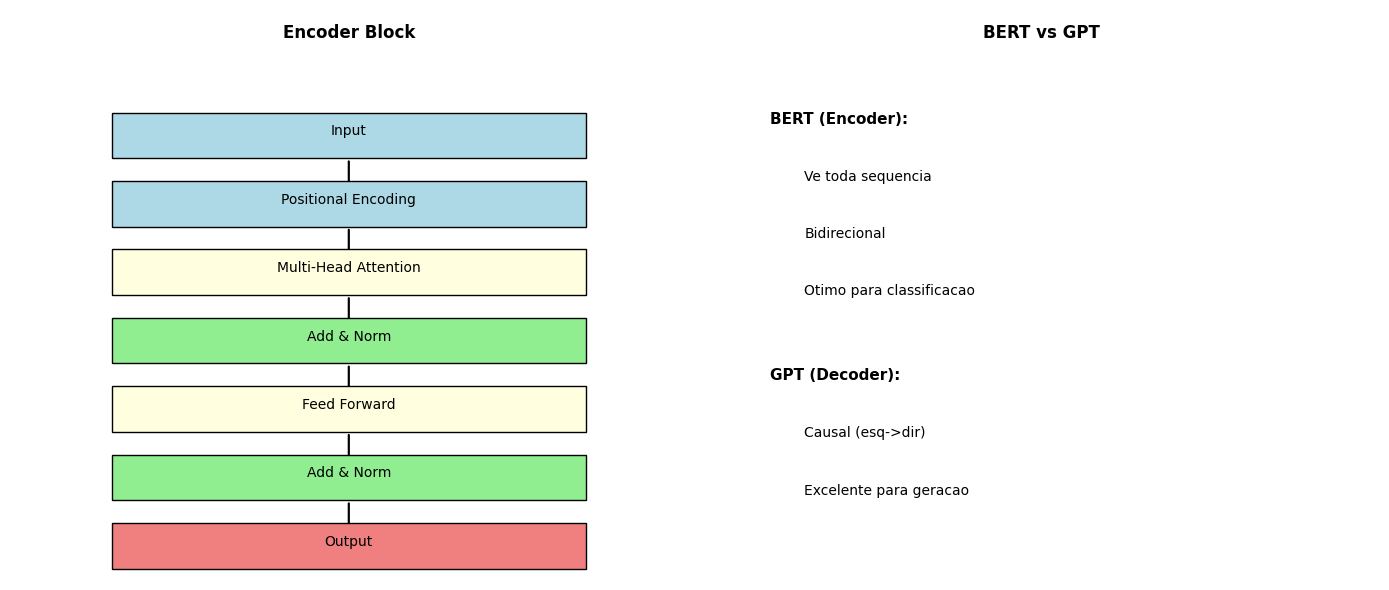

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.text(0.5, 0.95, 'Encoder Block', fontsize=12, weight='bold', ha='center')

y_pos = 0.8
blocks = ['Input', 'Positional Encoding', 'Multi-Head Attention', 'Add & Norm',
          'Feed Forward', 'Add & Norm', 'Output']
colors_block = ['lightblue', 'lightblue', 'lightyellow', 'lightgreen',
                'lightyellow', 'lightgreen', 'lightcoral']

for block, color in zip(blocks, colors_block):
    ax.add_patch(plt.Rectangle((0.15, y_pos-0.06), 0.7, 0.08,
                               fill=True, color=color, ec='black'))
    ax.text(0.5, y_pos-0.02, block, ha='center', fontsize=10)
    if y_pos > 0.2:
        ax.arrow(0.5, y_pos-0.065, 0, -0.05, head_width=0.1, head_length=0.03)
    y_pos -= 0.12

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax = axes[1]
ax.text(0.5, 0.95, 'BERT vs GPT', fontsize=12, weight='bold', ha='center')
ax.text(0.1, 0.80, 'BERT (Encoder):', fontsize=11, weight='bold')
ax.text(0.15, 0.70, 'Ve toda sequencia', fontsize=10)
ax.text(0.15, 0.60, 'Bidirecional', fontsize=10)
ax.text(0.15, 0.50, 'Otimo para classificacao', fontsize=10)

ax.text(0.1, 0.35, 'GPT (Decoder):', fontsize=11, weight='bold')
ax.text(0.15, 0.25, 'Causal (esq->dir)', fontsize=10)
ax.text(0.15, 0.15, 'Excelente para geracao', fontsize=10)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

### O que observar

- O encoder block tem: attention -> norm -> feedforward -> norm (com residual connections)
- Residual connections permitem gradientes fluirem diretamente (mesmo principio de ResNet em CNNs)
- BERT e encoder-only (bidirecional, bom para classificacao); GPT e decoder-only (causal, bom para geracao)
- Positional encoding e necessario porque attention nao tem nocao de ordem (diferente de RNN)

### O que concluir

- Transformers unificaram NLP: um unico modelo pre-treinado resolve multiplas tarefas
- A escala importa: modelos maiores (mais parametros, mais dados) sao consistentemente melhores
- O paradigma mudou: de "treinar do zero para cada tarefa" para "pre-treinar grande, fine-tune pequeno"
- A limitacao O(n^2) de attention esta sendo atacada por attention linear, sparse attention, etc.

### Conexao com outros notebooks

- Em **4.1 Fundamentos**, feedforward no Transformer e literalmente um MLP de 2 camadas
- Em **4.4 Transfer Learning**, o paradigma pre-train + fine-tune foi popularizado por BERT/GPT

## 9. Exercicios Praticos

### Exercicio 1: Convolucao com Kernels Customizados
Implemente e aplique kernels para deteccao de arestas diagonais.

In [10]:
# TAREFA DO ALUNO: Exercicio 1 - Kernels customizados
# 1. Crie um kernel que detecte arestas diagonais (\)
# 2. Aplique no padrao xadrez usando conv2d_simple
# 3. Visualize o resultado
kernel_diag = None  # TAREFA DO ALUNO: array 3x3 para arestas diagonais
feature_diag = None  # TAREFA DO ALUNO: resultado da convolucao

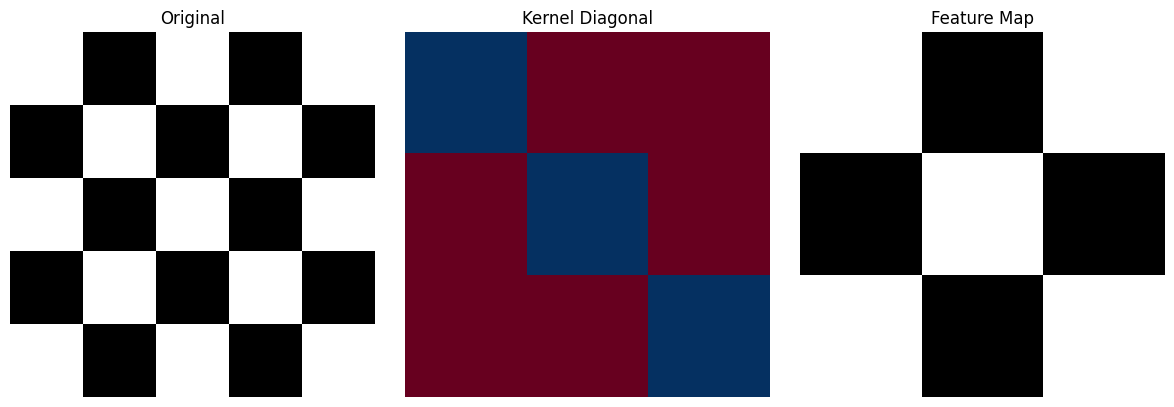

Kernel diagonal detecta padroes ao longo da diagonal principal


In [11]:
# SOLUCAO - Exercicio 1
image = np.array([
    [1, 0, 1, 0, 1],
    [0, 1, 0, 1, 0],
    [1, 0, 1, 0, 1],
    [0, 1, 0, 1, 0],
    [1, 0, 1, 0, 1]
])

kernel_diag = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])  # diagonal \

def conv2d_simple(image, kernel):
    h_i, w_i = image.shape
    h_k, w_k = kernel.shape
    output = np.zeros((h_i - h_k + 1, w_i - w_k + 1))
    for i in range(h_i - h_k + 1):
        for j in range(w_i - w_k + 1):
            output[i, j] = np.sum(image[i:i+h_k, j:j+w_k] * kernel)
    return output

feature_diag = conv2d_simple(image, kernel_diag)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(kernel_diag, cmap='RdBu')
axes[1].set_title('Kernel Diagonal')
axes[2].imshow(np.abs(feature_diag), cmap='gray')
axes[2].set_title('Feature Map')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

print('Kernel diagonal detecta padroes ao longo da diagonal principal')

### Exercicio 2: Sequencias com RNN Simples
Gere uma serie temporal sintetica e prepare os dados no formato sequencia -> predicao.

In [12]:
# TAREFA DO ALUNO: Exercicio 2 - Preparar dados para RNN
# 1. Gere serie: y[t] = sin(t) + noise
# 2. Crie sequencias de comprimento 10 para prever o proximo valor
# 3. Reporte o formato dos dados
X_seq = None  # TAREFA DO ALUNO: array (n_sequences, seq_length)
Y_seq = None  # TAREFA DO ALUNO: array (n_sequences,)

Sequencias: 116
Cada sequencia: 10 valores -> 1 predicao
Formato X: (116, 10), Y: (116,)


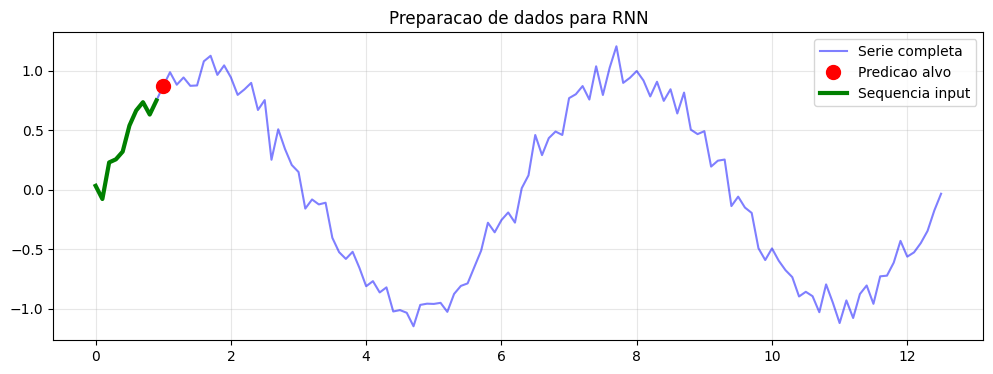

In [13]:
# SOLUCAO - Exercicio 2
t = np.arange(0, 4*np.pi, 0.1)
y = np.sin(t) + np.random.normal(0, 0.1, len(t))

def create_sequences(data, seq_length):
    X, Y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        Y.append(data[i+seq_length])
    return np.array(X), np.array(Y)

X_seq, Y_seq = create_sequences(y, seq_length=10)
print(f"Sequencias: {X_seq.shape[0]}")
print(f"Cada sequencia: {X_seq.shape[1]} valores -> 1 predicao")
print(f"Formato X: {X_seq.shape}, Y: {Y_seq.shape}")

plt.figure(figsize=(12, 4))
plt.plot(t, y, 'b-', alpha=0.5, label='Serie completa')
plt.plot(t[10:11], Y_seq[0:1], 'ro', markersize=10, label='Predicao alvo')
plt.plot(t[:10], X_seq[0], 'g-', linewidth=3, label='Sequencia input')
plt.legend()
plt.title('Preparacao de dados para RNN')
plt.grid(True, alpha=0.3)
plt.show()

### Exercicio 3: Attention Manual
Calcule attention weights manualmente para uma frase curta usando dot-product.

In [14]:
# TAREFA DO ALUNO: Exercicio 3 - Attention manual
# 1. Crie vetores Q, K, V para 4 palavras (dimensao 3)
# 2. Compute scores = Q @ K.T
# 3. Aplique softmax para obter pesos
# 4. Compute output = pesos @ V
Q = None  # TAREFA DO ALUNO: matrix (4, 3)
K = None  # TAREFA DO ALUNO: matrix (4, 3)
V = None  # TAREFA DO ALUNO: matrix (4, 3)

Attention Weights (cada linha = pesos para uma query):
[[0.176 0.278 0.4   0.147]
 [0.49  0.162 0.108 0.239]
 [0.329 0.135 0.061 0.476]
 [0.481 0.17  0.124 0.225]]

Output shape: (4, 3)
Cada query combina todos os values ponderados pela relevancia


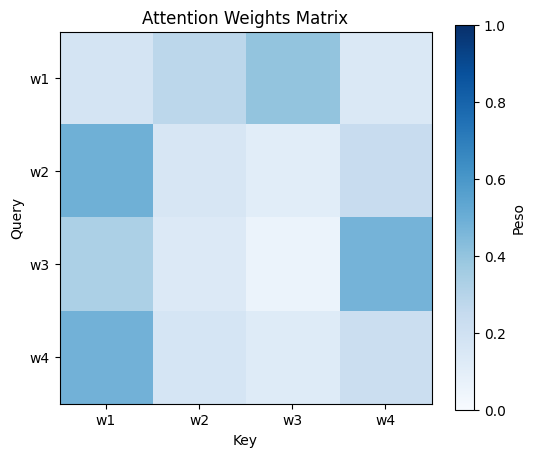

In [15]:
# SOLUCAO - Exercicio 3
import numpy as np

np.random.seed(42)
d_k = 3
Q = np.random.randn(4, d_k)  # 4 palavras, dim 3
K = np.random.randn(4, d_k)
V = np.random.randn(4, d_k)

# Scaled dot-product attention
scores = Q @ K.T / np.sqrt(d_k)

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

weights = softmax(scores)
output = weights @ V

print("Attention Weights (cada linha = pesos para uma query):")
print(np.round(weights, 3))
print(f"\nOutput shape: {output.shape}")
print("Cada query combina todos os values ponderados pela relevancia")

plt.figure(figsize=(6, 5))
plt.imshow(weights, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Peso')
plt.xlabel('Key')
plt.ylabel('Query')
plt.title('Attention Weights Matrix')
plt.xticks(range(4), ['w1', 'w2', 'w3', 'w4'])
plt.yticks(range(4), ['w1', 'w2', 'w3', 'w4'])
plt.show()

### O que observar nos exercicios

- Exercicio 1: kernels customizados mostram que convolucao e apenas multiplicacao + soma local
- Exercicio 2: preparar dados sequenciais requer criar janelas deslizantes (windowing)
- Exercicio 3: attention e basicamente multiplicacao de matrizes + softmax -- simples mas poderoso
- Todos os exercicios demonstram que as operacoes fundamentais sao simples; a magia esta na composicao

### O que concluir sobre os exercicios

- CNNs aprendem kernels melhores que os manuais -- nao precisamos projetar filtros
- O formato dos dados determina a arquitetura: 2D (CNN), sequencial (RNN), qualquer-para-qualquer (Transformer)
- Attention e facilmente implementavel e revelador: os pesos mostram o que o modelo "presta atencao"

### Conexao com outros notebooks

- Em **4.1 Fundamentos**, a base (neuronios, backprop) e reusada em todas estas arquiteturas
- Em **4.3 Treinamento**, tecnicas como batch norm e dropout se aplicam a CNNs, RNNs e Transformers

### Por que em ML?

A escolha da arquitetura e a decisao mais impactante em deep learning. CNN para dados com estrutura espacial, RNN/LSTM para sequencias curtas, Transformer para tudo que escala. Entender POR QUE cada arquitetura funciona e mais importante que memorizar detalhes.

### O que observar no panorama geral

- A evolucao CNN -> RNN -> LSTM -> Attention -> Transformer remove limitacoes progressivamente
- CNNs: localidade (bom), mas nao capturam relacoes globais
- RNNs: sequencialidade (bom), mas vanishing gradient e nao-paralelizavel
- Transformers: flexibilidade total, mas O(n^2) e alto custo computacional

### O que concluir sobre o panorama geral

- Na pratica moderna, Transformers dominam quase tudo (NLP, visao com ViT, audio)
- CNNs ainda sao fortes em visao computacional com recursos limitados
- RNNs/LSTMs sao cada vez menos usados, exceto em aplicacoes de baixa latencia
- A tendencia e modelos maiores pre-treinados adaptados via fine-tuning

### Conexao com outros notebooks

- Em **4.4 Transfer Learning**, veremos como usar estas arquiteturas pre-treinadas
- Em **4.5 Aceleracao**, o custo O(n^2) do Transformer e abordado

## 10. Erros Comuns e Armadilhas

### Erro 1: Usar MLP para Imagens

MLP ignora a estrutura espacial de imagens. Uma imagem 28x28 tem 784 inputs independentes para MLP, mas CNN sabe que pixels vizinhos sao correlacionados. Sempre usar CNN para dados com estrutura espacial.

### Erro 2: RNN para Sequencias Muito Longas

RNN simples sofre vanishing gradient em sequencias > 20 timesteps. Usar LSTM/GRU, ou melhor ainda, Transformer para sequencias longas.

### Erro 3: Treinar Transformer do Zero com Poucos Dados

Transformers precisam de MUITOS dados para funcionar bem. Com poucos dados, usar transfer learning (pre-treinado + fine-tune) em vez de treinar do zero.

### Erro 4: Ignorar Padding e Stride

Sem padding, cada convolucao reduz o tamanho da imagem. Sem stride adequado, o custo computacional explode. Entender padding='same' e stride>1 e essencial.

### Erro 5: Confundir Encoder e Decoder

BERT (encoder) e bom para classificacao e entendimento. GPT (decoder) e bom para geracao. Usar a arquitetura errada para a tarefa e um erro comum.

### Erro 6: Nao Usar Residual Connections em Redes Profundas

Sem skip connections, redes com >20 camadas sao praticamente intreinaveis. Residual connections sao obrigatorias em arquiteturas profundas modernas.

### Erro 7: Pensar que Mais Camadas = Sempre Melhor

Alem de certo ponto, mais camadas sem dados suficientes causa overfitting. A profundidade ideal depende do volume de dados e da complexidade do problema.

## 11. Resumo e Conexoes

### Hierarquia de Conceitos

```
Arquiteturas Deep Learning
|-- CNNs (dados espaciais)
|   |-- Convolucao (localidade + weight sharing)
|   |-- Pooling (reducao + invariancia)
|   +-- Arquiteturas: LeNet -> AlexNet -> VGG -> ResNet -> EfficientNet
|-- RNNs (dados sequenciais)
|   |-- RNN simples (vanishing gradient)
|   |-- LSTM (gates + cell state)
|   +-- GRU (simplificacao do LSTM)
|-- Attention (relacoes arbitrarias)
|   |-- Dot-product attention (Q, K, V)
|   +-- Multi-head attention
+-- Transformers (estado da arte)
    |-- Encoder (BERT, classificacao)
    |-- Decoder (GPT, geracao)
    +-- Encoder-Decoder (T5, traducao)
```

### Conexoes com Outros Notebooks

| Conceito | Notebook | Relacao |
|----------|----------|---------|
| MLP base | 4.1 Fundamentos | Transformer FFN = MLP de 2 camadas |
| Backprop | 4.1 Fundamentos | BPTT em RNN = backprop unrolled |
| Regularizacao | 4.3 Treinamento | Dropout, BatchNorm se aplicam a todas |
| Transfer learning | 4.4 Transfer | Pre-treinar + fine-tune |
| Aceleracao | 4.5 Hardware | GPU essencial para treinar estas redes |
| Kernel trick | 3.4 SVM | Attention ~= kernel adaptativo |

### Checklist de Competencias

- [ ] Explicar por que CNNs sao melhores que MLPs para imagens
- [ ] Implementar convolucao 2D e max pooling do zero
- [ ] Explicar vanishing gradient em RNNs e como LSTM resolve
- [ ] Descrever o mecanismo de attention (Q, K, V)
- [ ] Diferenciar encoder (BERT) e decoder (GPT)
- [ ] Escolher a arquitetura adequada para cada tipo de dados
- [ ] Explicar residual connections e por que sao necessarias

### Proximos Passos

No notebook **4.3 Treinamento Deep**, veremos como treinar estas arquiteturas na pratica: otimizadores (Adam, SGD), learning rate schedules, batch normalization, dropout, e data augmentation.